<a href="https://colab.research.google.com/github/novafluz/used-car-price-prediction/blob/main/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Library

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

### Load Dataset

In [ ]:
# load dataset from kagglehub if you're opening from collab
DATAPATH = '../data/used_cars.csv' 
car_data = pd.read_csv(DATAPATH)

### Dataset Overview

In [4]:
car_data.head(5) # show first 5 rows

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
car_data.tail(5) # show last 5 rows

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [6]:
# show shape of data
print(f"Shape of data: {car_data.shape}\n")

# check schema
print("Data Schema:")
print(car_data.info())

Shape of data: (4009, 12)

Data Schema:
<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB
None


In [7]:
# check null data
print(f"Columns that have null data: \n{car_data.isnull().sum()}")

Columns that have null data: 
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [8]:
car_data.duplicated().sum()

np.int64(0)

In [9]:
car_data.describe(include="number")

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [10]:
car_data.describe(include="str")

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [16]:
# convert variables into numeric forms, create new numeric features to visualize

car_data['price'] = car_data['price'].str.replace('$','', regex=False).str.replace(',','').astype(float)
car_data['milage'] = car_data['milage'].str.replace('[, mi.]', '', regex=True).astype(float)
car_data['car_age'] = datetime.now().year - car_data['model_year']
car_data['milage_per_year'] = car_data['milage'] / car_data['car_age']

# Extract HP, volume, cylinder
car_data['engine_hp'] = car_data['engine'].str.extract(r'(\d+\.?\d*)\s*HP').astype(float)
car_data['engine_size'] = car_data['engine'].str.extract(r'(\d+\.?\d*)\s*L').astype(float)
car_data['engine_cylinders'] = car_data['engine'].str.extract(r'(\d+)\s*Cylinder').astype(float)

# Handle missing values
car_data['engine_hp'] = car_data['engine_hp'].fillna(car_data['engine_hp'].median())
car_data['engine_size'] = car_data['engine_size'].fillna(car_data['engine_size'].median())
car_data['engine_cylinders'] = car_data['engine_cylinders'].fillna(car_data['engine_cylinders'].median())

### Visualize data

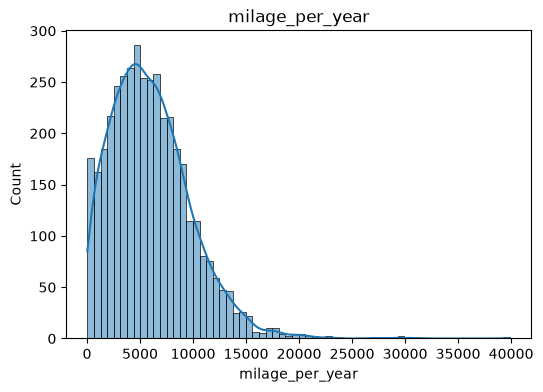

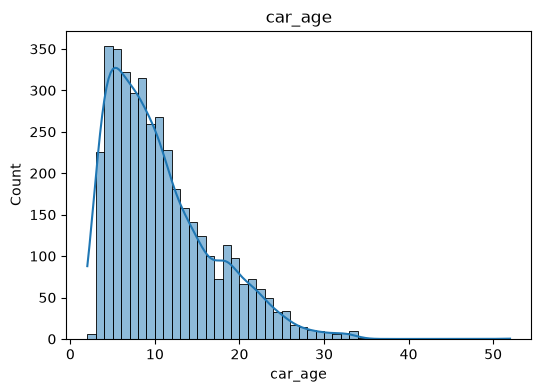

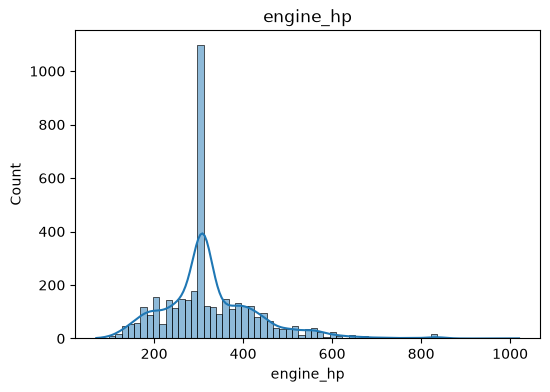

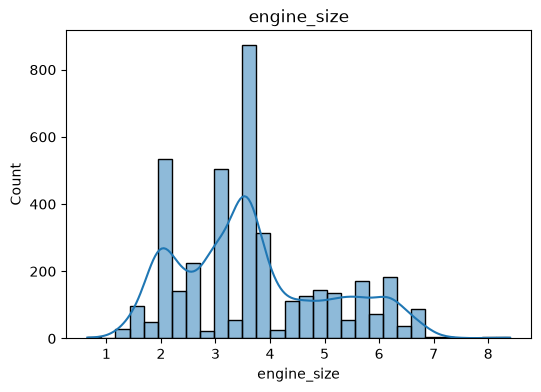

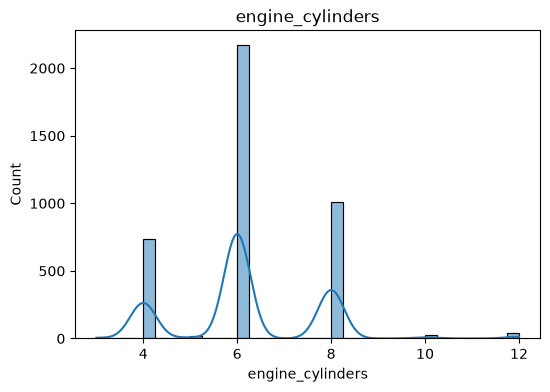

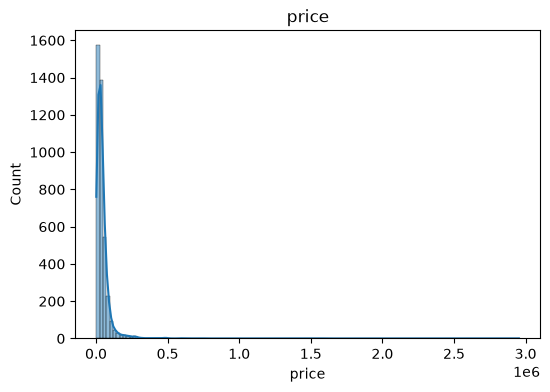

In [ ]:
num_cols = ['milage_per_year', 'car_age', 'engine_hp', 'engine_size', 'engine_cylinders', 'price']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(car_data[col], kde=True) 
    plt.title(col)
    plt.show()

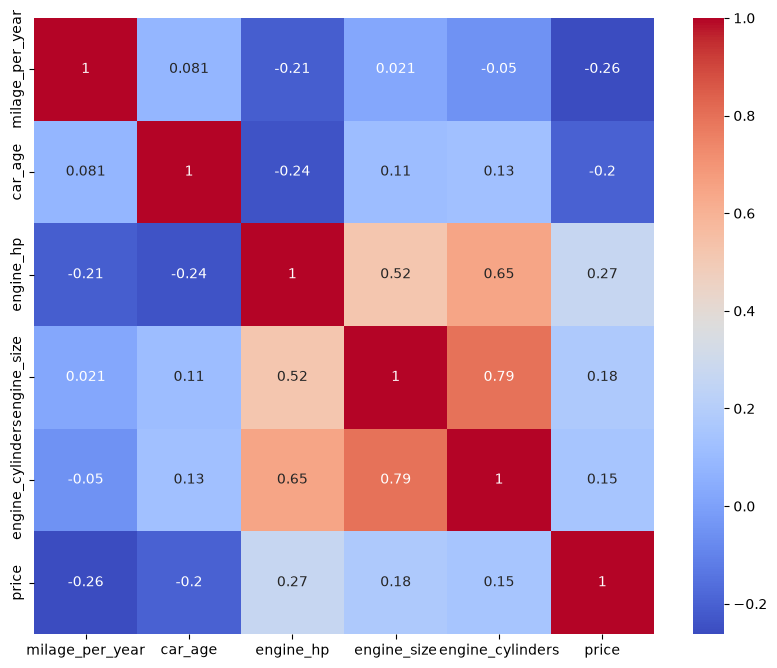

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(data=car_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

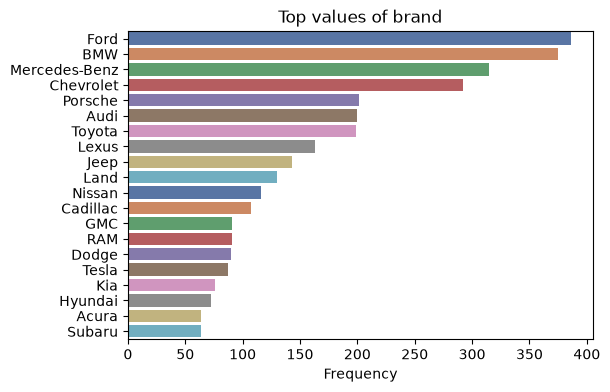

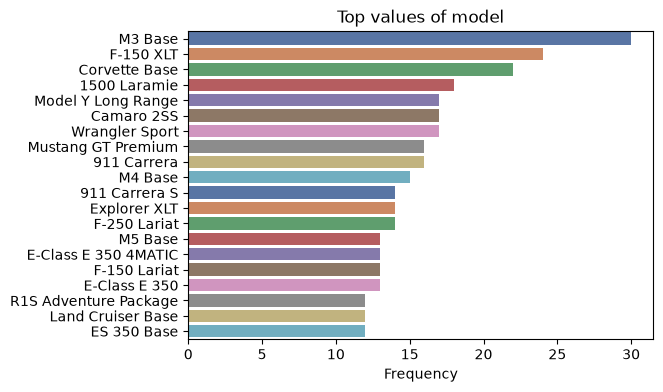

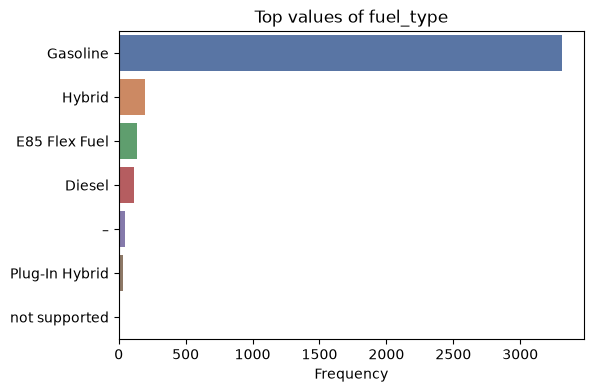

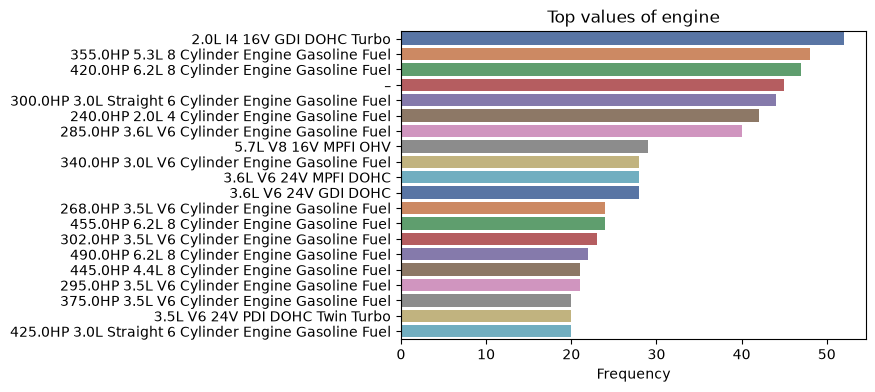

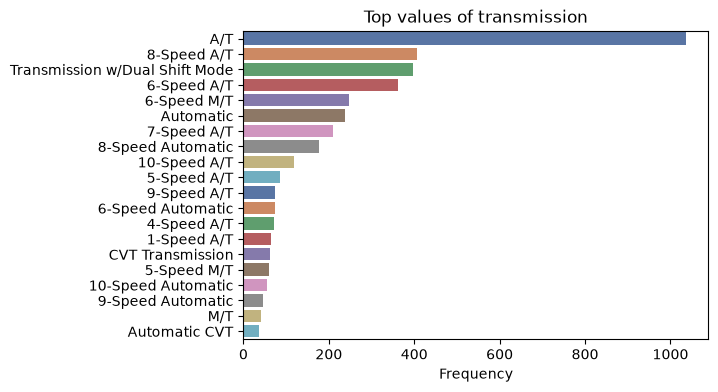

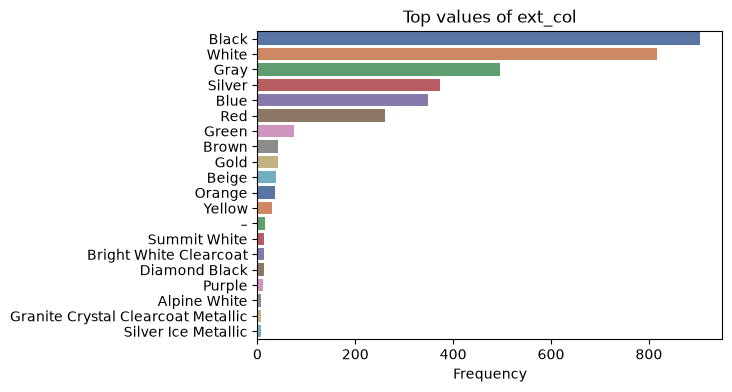

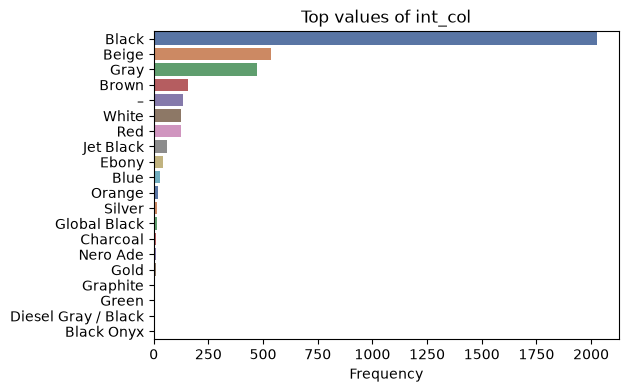

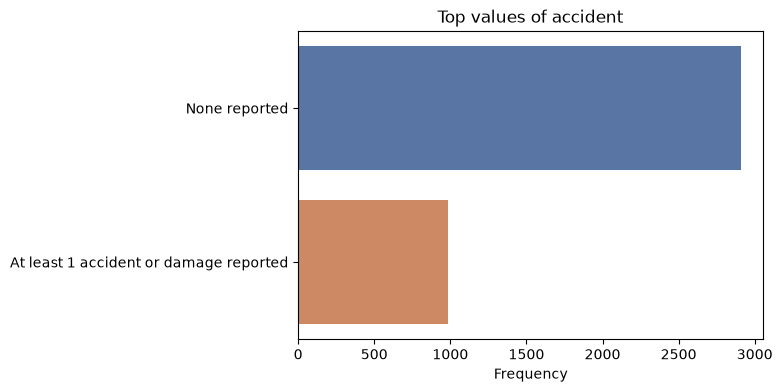

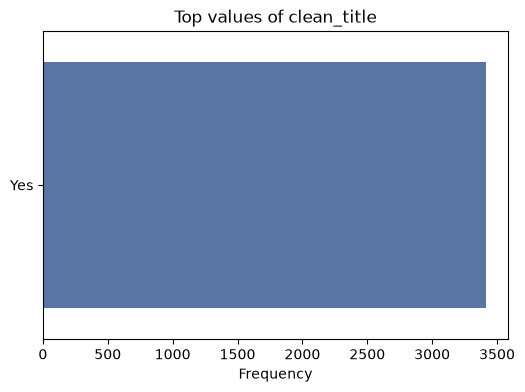

In [25]:
cat_cols = car_data.select_dtypes(include = ['str']).columns
for col in cat_cols:
    plt.figure(figsize = (6, 4))
    frequency = car_data[col].value_counts().head(20)
    plt.title(f"Top values of {col}")
    sns.barplot(x=frequency.values, y=frequency.index, hue=frequency.index, palette='deep', legend=False)
    plt.ylabel('')
    plt.xlabel('Frequency')
    plt.show()